# Stage 9 - VaR and fidelity check

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.stages import fidelity_table, acceptance_check, recalibration_loop, config_snapshot
from src.noise_model import ControlDrift
from src.pipeline_io import load_stage_output, save_json, save_fig
from src.report import write_final_report

BLUE, RED, GREEN, GREY, ORANGE, PURPLE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22", "#8e44ad"
COLORS = {"ideal_noiseless": BLUE, "noisy_uncalibrated": RED, "uncalibrated_REM": "#f1948a",
          "6A_grid_REM": ORANGE, "6B_auto_REM": GREEN, "6B_auto_REM_ZNE": PURPLE}

s6 = load_stage_output("stage06_retuning.json")
s7 = load_stage_output("stage07_execution.json")
s8 = load_stage_output("stage08_postprocessing.json")

tables = {}
for n in C.REGISTER_SIZES:
    key = f"{n}_qubit"
    tables[n] = fidelity_table(n, s7[key], s8[key])
    cl = s8[key]["classical"]
    print(f"=== {n}-qubit register ===   classical VaR95: discrete grid = ${cl['classical_discrete_grid']['var']:.0f}, "
          f"Monte Carlo = ${cl['classical_monte_carlo_continuous']['var']:.0f}")
    print(f"{'variant':18s} | {'F vs ideal':>15} | {'F vs classical':>14} | {'F loss':>6} | {'F z':>6} | "
          f"{'VaR95':>5} | {'VaR ok in all reps':>18}")
    for k, r in tables[n].items():
        print(f"{k:18s} | {r['F_vs_ideal_mean']:.4f} +/- {r['F_vs_ideal_std']:.4f} | "
              f"{r['F_vs_classical_joint_mean']:14.4f} | {r['F_loss_distribution_vs_classical']:6.4f} | "
              f"{r['F_z_marginal_vs_target_gaussian']:6.4f} | {r['VaR95']:5.0f} | {str(r['VaR95_all_repeats_match']):>18}")
    print()

=== 2-qubit register ===   classical VaR95: discrete grid = $1000, Monte Carlo = $1000
variant            |      F vs ideal | F vs classical | F loss |    F z | VaR95 | VaR ok in all reps
ideal_noiseless    | 1.0000 +/- 0.0000 |         1.0000 | 1.0000 | 1.0000 |  1000 |               True
noisy_uncalibrated | 0.8794 +/- 0.0026 |         0.8802 | 0.9913 | 0.8940 |  1000 |               True
uncalibrated_REM   | 0.9218 +/- 0.0027 |         0.9226 | 0.9889 | 0.9396 |  1000 |               True
6A_grid_REM        | 0.9391 +/- 0.0022 |         0.9394 | 1.0000 | 0.9437 |  1000 |               True
6B_auto_REM        | 0.9819 +/- 0.0016 |         0.9820 | 0.9993 | 0.9837 |  1000 |               True
6B_auto_REM_ZNE    | 0.9983 +/- 0.0007 |         0.9983 | 0.9999 | 0.9994 |  1000 |               True

=== 3-qubit register ===   classical VaR95: discrete grid = $1000, Monte Carlo = $1000
variant            |      F vs ideal | F vs classical | F loss |    F z | VaR95 | VaR ok in all reps
ideal

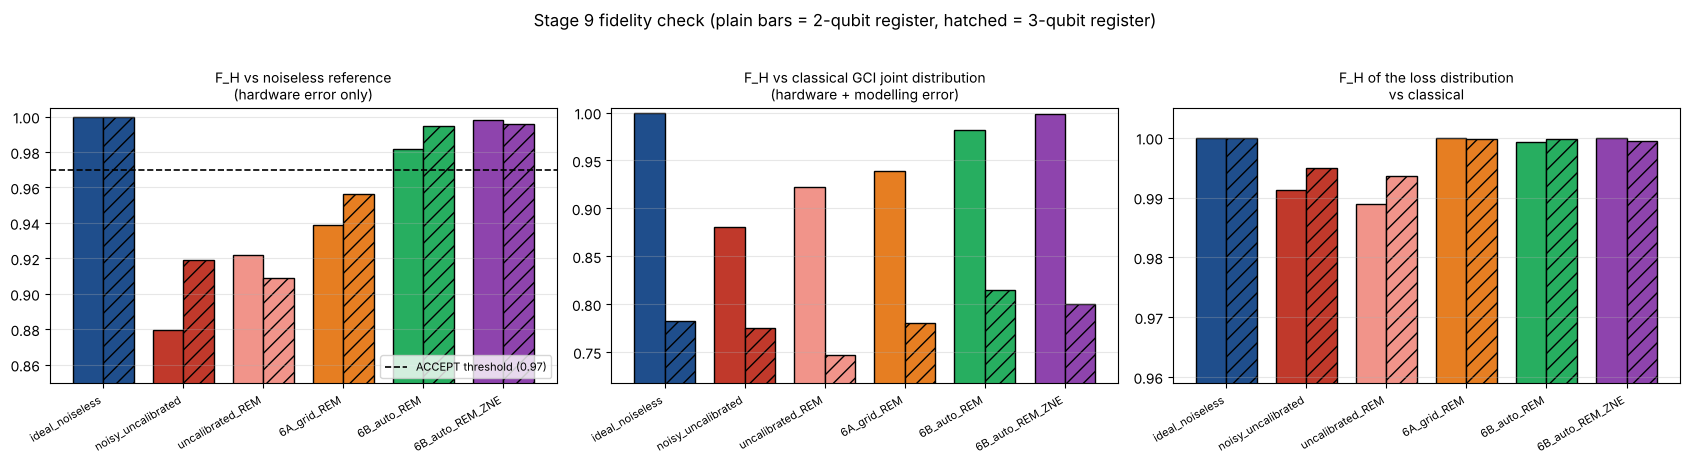

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
keys = list(tables[2])
metrics = [("F_vs_ideal_mean", "F_H vs noiseless reference\n(hardware error only)"),
           ("F_vs_classical_joint_mean", "F_H vs classical GCI joint distribution\n(hardware + modelling error)"),
           ("F_loss_distribution_vs_classical", "F_H of the loss distribution\nvs classical")]
for ax, (m, title) in zip(axes, metrics):
    x = np.arange(len(keys)); w = 0.38
    for j, n in enumerate(C.REGISTER_SIZES):
        vals = [tables[n][k][m] for k in keys]
        ax.bar(x + (j - 0.5) * w, vals, w, color=[COLORS[k] for k in keys], edgecolor="k",
               hatch="" if n == 2 else "//")
    if m == "F_vs_ideal_mean":
        ax.axhline(C.FIDELITY_THRESHOLD, color="k", ls="--", lw=1.2, label=f"ACCEPT threshold ({C.FIDELITY_THRESHOLD})")
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xticks(x); ax.set_xticklabels(keys, rotation=30, ha="right", fontsize=8)
    lo = min(tables[n][k][m] for n in C.REGISTER_SIZES for k in keys)
    ax.set_ylim(max(0.0, lo - 0.03), 1.005); ax.set_title(title, fontsize=10); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Stage 9 fidelity check (plain bars = 2-qubit register, hatched = 3-qubit register)", y=1.02)
plt.tight_layout(); save_fig(fig, "stage09_fidelity_summary.png"); plt.show()

In [4]:
decisions = {}
for n in C.REGISTER_SIZES:
    f = tables[n]["6B_auto_REM"]["F_vs_ideal_mean"]
    decisions[n] = acceptance_check(f)
    print(f"{n}-qubit register: F_H(6B + REM) = {f:.4f}  vs threshold {C.FIDELITY_THRESHOLD}  ->  {decisions[n]}")

2-qubit register: F_H(6B + REM) = 0.9819  vs threshold 0.97  ->  ACCEPT
3-qubit register: F_H(6B + REM) = 0.9946  vs threshold 0.97  ->  ACCEPT


In [5]:
loops = {}
for n in C.REGISTER_SIZES:
    x6b = s6[f"{n}_qubit"]["calibrated_parameters"]["auto_6B"]
    print(f"=== {n}-qubit register — today's chip (the one Stage 6 calibrated on) ===")
    day1 = recalibration_loop(n, x6b, ControlDrift())
    print(f"=== {n}-qubit register — after the drift event ===")
    day2 = recalibration_loop(n, x6b, ControlDrift(C.DRIFT_EPS_DAY2, C.DRIFT_DELTA_DEG_DAY2))
    grid_cost = s6[f"{n}_qubit"]["gci"]["methods"]["grid_6A"]["n_evals"]
    print(f"   automatic re-calibration cost: {day2['total_recalibration_evals']} circuit runs "
          f"(a manual 6A re-sweep would cost {grid_cost})\n")
    loops[n] = (day1, day2)

=== 2-qubit register — today's chip (the one Stage 6 calibrated on) ===


  round 0: F_H = 0.9818  ->  ACCEPT
=== 2-qubit register — after the drift event ===


  round 0: F_H = 0.5283  ->  RE-CALIBRATE


     re-ran Stage 6B automatically (204 circuit evaluations)
  round 1: F_H = 0.9715  ->  ACCEPT
   automatic re-calibration cost: 204 circuit runs (a manual 6A re-sweep would cost 347)

=== 3-qubit register — today's chip (the one Stage 6 calibrated on) ===


  round 0: F_H = 0.9943  ->  ACCEPT
=== 3-qubit register — after the drift event ===


  round 0: F_H = 0.6761  ->  RE-CALIBRATE


     re-ran Stage 6B automatically (204 circuit evaluations)
  round 1: F_H = 0.9917  ->  ACCEPT
   automatic re-calibration cost: 204 circuit runs (a manual 6A re-sweep would cost 477)



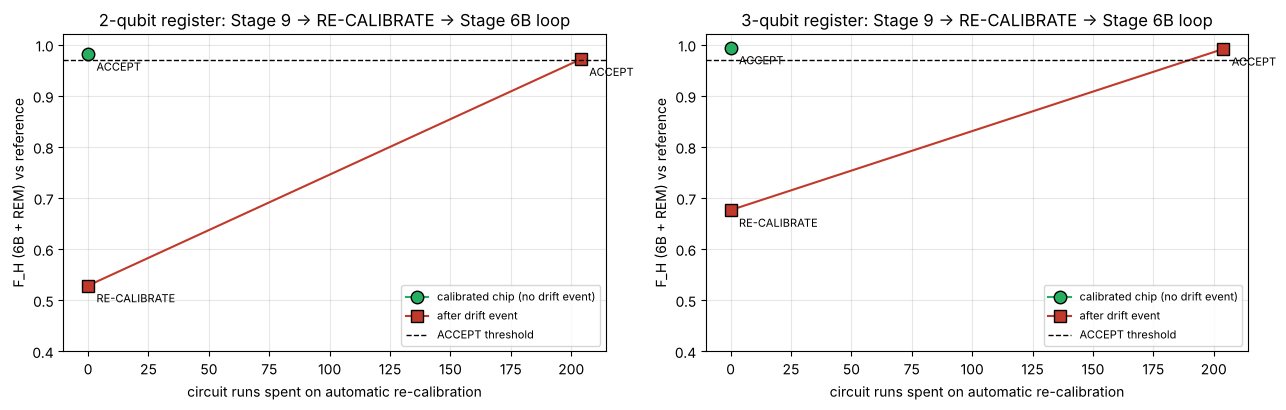

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, n in zip(axes, C.REGISTER_SIZES):
    for (loop, lab, col, mk) in [(loops[n][0], "calibrated chip (no drift event)", GREEN, "o"),
                                 (loops[n][1], "after drift event", RED, "s")]:
        r = loop["rounds"]
        xs = [x["cumulative_calibration_evals"] for x in r]
        ys = [x["fidelity"] for x in r]
        ax.plot(xs, ys, "-" + mk, color=col, ms=9, mec="k", label=lab)
        for x, y, d in zip(xs, ys, [x["decision"] for x in r]):
            ax.annotate(d, (x, y), textcoords="offset points", xytext=(6, -12), fontsize=8)
    ax.axhline(C.FIDELITY_THRESHOLD, color="k", ls="--", lw=1, label="ACCEPT threshold")
    ax.set_xlabel("circuit runs spent on automatic re-calibration"); ax.set_ylabel("F_H (6B + REM) vs reference")
    ax.set_title(f"{n}-qubit register: Stage 9 -> RE-CALIBRATE -> Stage 6B loop")
    ax.set_ylim(0.4, 1.02); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); save_fig(fig, "stage09_recalibration_loop.png"); plt.show()

In [7]:
out = {"config": config_snapshot(), "threshold": C.FIDELITY_THRESHOLD}
for n in C.REGISTER_SIZES:
    key = f"{n}_qubit"
    out[key] = {"fidelity_table": tables[n], "deployed_pipeline": "6B_auto_REM",
                "deployed_fidelity": tables[n]["6B_auto_REM"]["F_vs_ideal_mean"], "decision": decisions[n],
                "loop_day1": loops[n][0], "loop_day2_drift_event": loops[n][1],
                "classical_var95": s8[key]["classical"]["classical_discrete_grid"]["var"],
                "classical_mc_var95": s8[key]["classical"]["classical_monte_carlo_continuous"]["var"]}
path = save_json(out, "stage09_final_report.json")
rpath = write_final_report(s6, s7, s8, out)
print(f"Saved -> {path}\nSaved -> {rpath}\n")
print(open(rpath).read())

Saved -> /home/claude/repo/results/stage09_final_report.json
Saved -> /home/claude/repo/results/FINAL_REPORT.md

# Final Report — Quantum Circuit-Based Adaptation for Credit Risk Analysis

Replication (on a noise-emulated Qiskit simulator) of Ahmad et al., *IEEE Trans. Quantum Eng.* 7, 3103316 (2026), with an automated calibration loop replacing the paper's manual grid sweep.

Model: one asset, one latent factor, p0 = 0.25, rho = 0.027, LGD = $1000. Registers studied: 2-qubit, 3-qubit latent-factor register (+1 asset qubit).

## Stage 6 — calibration cost vs. quality (full GCI circuit)

| register | method | circuit runs | F_H vs noiseless reference |
|---|---|---|---|
| 2q | uncalibrated (Stage 4 angles) | 0 | 0.9225 |
| 2q | 6A grid sweep (base paper) | 347 | 0.9389 |
| 2q | **6B automated (this project)** | 204 | 0.9818 |
| 2q | ablation: joint SPSA | 308 | 0.9820 |
| 2q | ablation: joint BO | 70 | 0.9727 |
| 3q | uncalibrated (Stage 4 angles) | 0 | 0.9099 |
| 3q | 6A grid sweep (ba